<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/63_Lab3_Forecast_Uncertainty_Robust_Decision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3. Forecast Uncertainty → Robust Decision
### 예측 불확실성에서 강건 의사결정으로 / From Forecast Uncertainty to Robust Decision

이 실습은 **점예측만 쓰는 의사결정**과 **불확실성을 반영하는 의사결정**을 비교합니다.  
This lab compares **point-forecast decisions** with **uncertainty-aware robust decisions**.

---
**학습목표 / Learning Objectives**
1. 예측오차와 불확실성의 의미를 이해한다.  
   Understand the meaning of forecast error and uncertainty.
2. 점예측 기반 주문량과 시나리오 기반 주문량을 비교한다.  
   Compare point-forecast orders with scenario-based robust orders.
3. 불확실성을 반영하면 평균적으로 더 안정적인 의사결정이 가능한지 확인한다.  
   Examine whether uncertainty-aware decisions are more stable on average.

In [1]:
# Colab 권장 설치 셀 / Recommended installation cell
!pip -q install yfinance statsmodels scipy openpyxl

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize
from statsmodels.tsa.arima.model import ARIMA
from IPython.display import display, Markdown

np.random.seed(42)


def bilingual_title(kr, en):
    display(Markdown(f"## {kr}<br><span style='font-size:0.9em;color:#666'>{en}</span>"))


def bilingual_text(kr, en):
    display(Markdown(f"**[KR]** {kr}<br>**[EN]** {en}"))


def summary_box(title_kr, title_en, bullets_kr, bullets_en):
    kr = '<br>'.join([f"- {x}" for x in bullets_kr])
    en = '<br>'.join([f"- {x}" for x in bullets_en])
    display(Markdown(f"### {title_kr}<br><span style='font-size:0.9em;color:#666'>{title_en}</span><br><br>**[KR]**<br>{kr}<br><br>**[EN]**<br>{en}"))

## 1. 데이터 생성<br><span style='font-size:0.9em;color:#666'>1. Generate demand data</span>

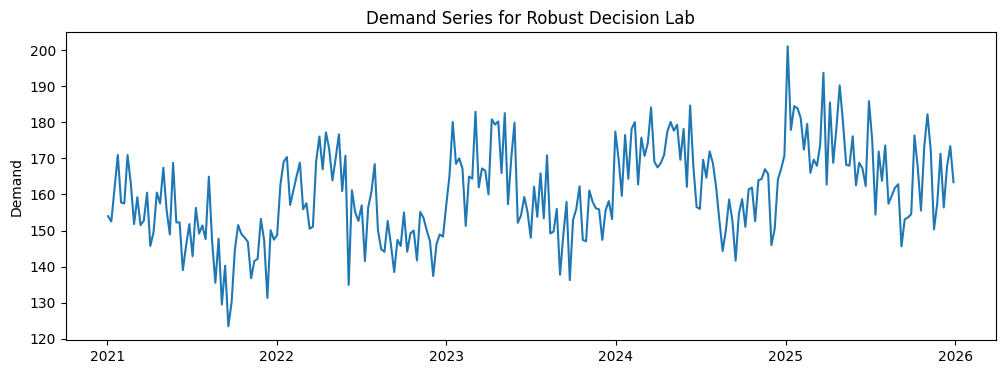

In [3]:
bilingual_title("1. 데이터 생성", "1. Generate demand data")

dates = pd.date_range('2021-01-03', '2025-12-28', freq='W')
t = np.arange(len(dates))
demand = (
    150
    + 0.08 * t
    + 10 * np.sin(2*np.pi*t/52)
    + 5 * np.sin(2*np.pi*t/13)
    + np.random.normal(0, 8, len(t))
)
demand = np.maximum(demand, 40)
ts = pd.Series(demand, index=dates, name='demand')

train = ts[:'2024-12-29']
test = ts['2025-01-05':]

plt.figure(figsize=(12,4))
plt.plot(ts.index, ts.values)
plt.title('Demand Series for Robust Decision Lab')
plt.ylabel('Demand')
plt.show()

## 2. ARIMA 예측 및 불확실성 추정<br><span style='font-size:0.9em;color:#666'>2. ARIMA forecast and uncertainty estimation</span>

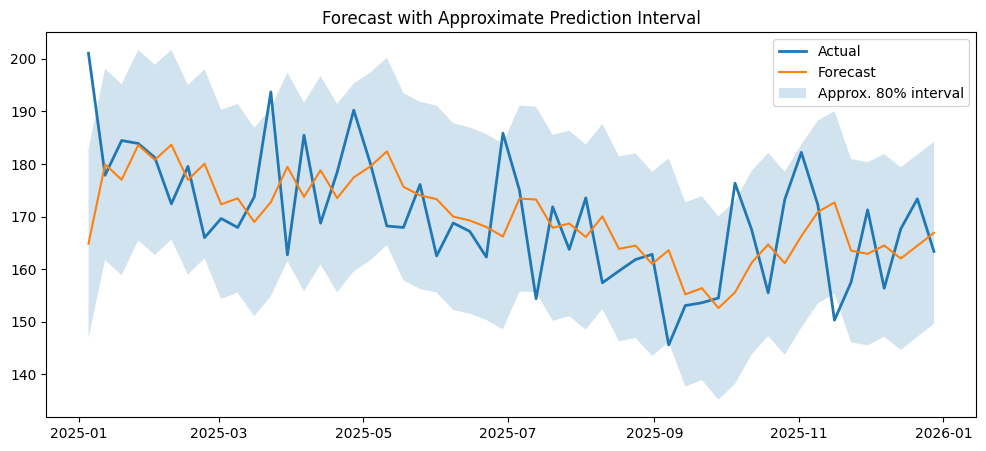

In [4]:
bilingual_title("2. ARIMA 예측 및 불확실성 추정", "2. ARIMA forecast and uncertainty estimation")

history = list(train.values)
preds = []
lower = []
upper = []
sigma_hist = []

residual_pool = []
init_fit = ARIMA(train.values, order=(2,1,2)).fit()
base_sigma = np.std(init_fit.resid)

for actual in test.values:
    fit = ARIMA(history, order=(2,1,2)).fit()
    fc = fit.forecast(steps=1)[0]
    sigma = np.std(fit.resid) if len(fit.resid) > 5 else base_sigma

    preds.append(fc)
    lower.append(fc - 1.28 * sigma)
    upper.append(fc + 1.28 * sigma)
    sigma_hist.append(sigma)
    history.append(actual)

pred = pd.Series(preds, index=test.index)
lower = pd.Series(lower, index=test.index)
upper = pd.Series(upper, index=test.index)
sigma_hist = pd.Series(sigma_hist, index=test.index)

plt.figure(figsize=(12,5))
plt.plot(test.index, test.values, label='Actual', linewidth=2)
plt.plot(pred.index, pred.values, label='Forecast')
plt.fill_between(test.index, lower.values, upper.values, alpha=0.2, label='Approx. 80% interval')
plt.title('Forecast with Approximate Prediction Interval')
plt.legend()
plt.show()

In [5]:
bilingual_title("3. 세 가지 의사결정 규칙", "3. Three decision rules")

holding_cost = 2
shortage_cost = 8

# 1) Point forecast decision
q_point = np.ceil(pred)

# 2) Safety stock decision
service_level = shortage_cost / (holding_cost + shortage_cost)
z = norm.ppf(service_level)
q_safety = np.ceil(pred + z * sigma_hist)

# 3) Robust scenario decision
def decision_cost(q, demand):
    return holding_cost * max(q - demand, 0) + shortage_cost * max(demand - q, 0)

q_robust = []
for f, s in zip(pred.values, sigma_hist.values):
    scenarios = np.array([f - s, f, f + s])
    probs = np.array([0.2, 0.5, 0.3])
    q_grid = np.arange(max(0, int(f - 2*s)), int(f + 2*s) + 1)
    exp_costs = []
    for q in q_grid:
        exp_cost = np.sum([p * decision_cost(q, d) for p, d in zip(probs, scenarios)])
        exp_costs.append(exp_cost)
    q_star = q_grid[np.argmin(exp_costs)]
    q_robust.append(q_star)
q_robust = pd.Series(q_robust, index=test.index)

## 3. 세 가지 의사결정 규칙<br><span style='font-size:0.9em;color:#666'>3. Three decision rules</span>

In [6]:
bilingual_title("4. 실제 비용 평가", "4. Evaluate realized costs")

def realized_costs(order_series, actual_series):
    order = order_series.values
    actual = actual_series.values
    hold = np.maximum(order - actual, 0)
    short = np.maximum(actual - order, 0)
    return pd.DataFrame({
        'HoldingCost': holding_cost * hold,
        'ShortageCost': shortage_cost * short,
        'TotalCost': holding_cost * hold + shortage_cost * short
    }, index=actual_series.index)

cost_point = realized_costs(q_point, test)
cost_safety = realized_costs(q_safety, test)
cost_robust = realized_costs(q_robust, test)

result = pd.DataFrame({
    'Rule': ['PointForecast', 'SafetyStock', 'RobustScenario'],
    'AvgOrderQty': [q_point.mean(), q_safety.mean(), q_robust.mean()],
    'HoldingCost': [cost_point['HoldingCost'].sum(), cost_safety['HoldingCost'].sum(), cost_robust['HoldingCost'].sum()],
    'ShortageCost': [cost_point['ShortageCost'].sum(), cost_safety['ShortageCost'].sum(), cost_robust['ShortageCost'].sum()],
    'TotalCost': [cost_point['TotalCost'].sum(), cost_safety['TotalCost'].sum(), cost_robust['TotalCost'].sum()]
}).sort_values('TotalCost')

display(result)

## 4. 실제 비용 평가<br><span style='font-size:0.9em;color:#666'>4. Evaluate realized costs</span>

,Rule,AvgOrderQty,HoldingCost,ShortageCost,TotalCost
1,SafetyStock,181.942308,1367.647115,429.847814,1797.494929
2,RobustScenario,183.500000,1510.677789,353.970512,1864.648301
0,PointForecast,170.307692,466.076822,1663.566642,2129.643464


## 5. 비용 비교 그래프<br><span style='font-size:0.9em;color:#666'>5. Compare total costs</span>

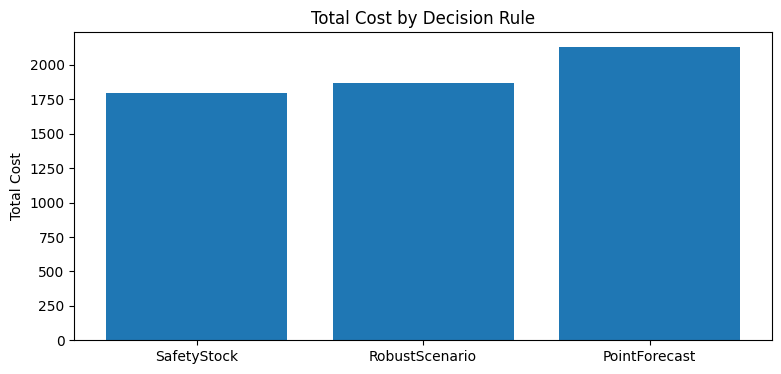

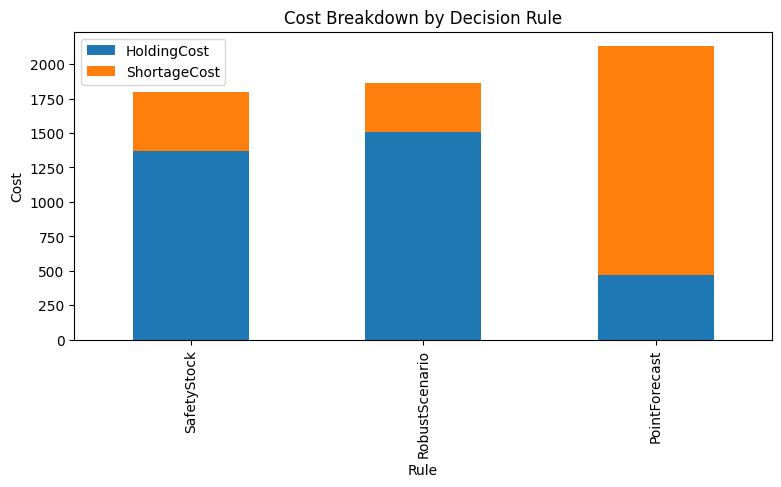

In [7]:
bilingual_title("5. 비용 비교 그래프", "5. Compare total costs")

plt.figure(figsize=(9,4))
plt.bar(result['Rule'], result['TotalCost'])
plt.title('Total Cost by Decision Rule')
plt.ylabel('Total Cost')
plt.show()

result.set_index('Rule')[['HoldingCost', 'ShortageCost']].plot(kind='bar', stacked=True, figsize=(9,4))
plt.title('Cost Breakdown by Decision Rule')
plt.ylabel('Cost')
plt.show()

## 6. 특정 시점에서의 강건 선택<br><span style='font-size:0.9em;color:#666'>6. Robust choice for a sample period</span>

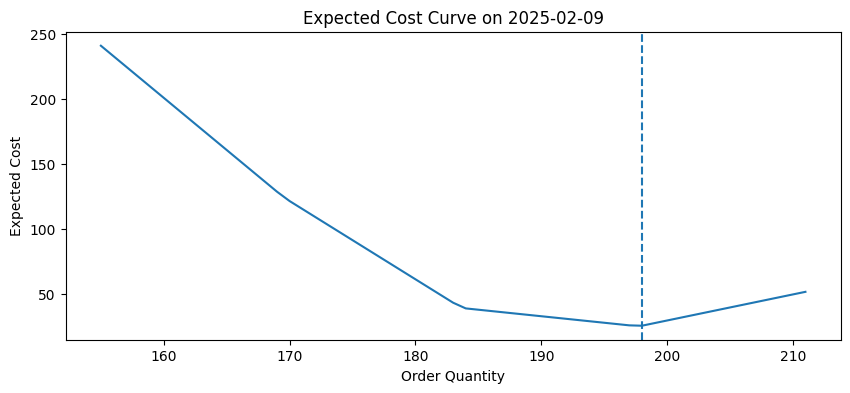

**[KR]** 예시 시점 2025-02-09에서는 주문량을 너무 낮게 두면 품절비용이 커지고, 너무 높게 두면 보유비용이 커집니다.<br>**[EN]** For the sample period 2025-02-09, too low an order quantity increases shortage cost, while too high an order quantity increases holding cost.

In [8]:
bilingual_title("6. 특정 시점에서의 강건 선택", "6. Robust choice for a sample period")

sample_date = test.index[5]
f = pred.loc[sample_date]
s = sigma_hist.loc[sample_date]
scenarios = np.array([f - s, f, f + s])
probs = np.array([0.2, 0.5, 0.3])
q_grid = np.arange(max(0, int(f - 2*s)), int(f + 2*s) + 1)
exp_costs = [np.sum([p * decision_cost(q, d) for p, d in zip(probs, scenarios)]) for q in q_grid]

plt.figure(figsize=(10,4))
plt.plot(q_grid, exp_costs)
plt.axvline(q_grid[np.argmin(exp_costs)], linestyle='--')
plt.title(f'Expected Cost Curve on {sample_date.date()}')
plt.xlabel('Order Quantity')
plt.ylabel('Expected Cost')
plt.show()

bilingual_text(
    f"예시 시점 {sample_date.date()}에서는 주문량을 너무 낮게 두면 품절비용이 커지고, 너무 높게 두면 보유비용이 커집니다.",
    f"For the sample period {sample_date.date()}, too low an order quantity increases shortage cost, while too high an order quantity increases holding cost."
)

In [9]:
bilingual_title("7. 결과 해석", "7. Interpretation")

best_rule = result.iloc[0]['Rule']
bilingual_text(
    f"총비용 기준 가장 우수한 의사결정 규칙은 {best_rule}입니다.",
    f"The best decision rule by total cost is {best_rule}."
)

summary_box(
    "핵심 해석",
    "Key Interpretation",
    [
        "점예측만 사용하면 예측오차에 취약할 수 있다.",
        "안전재고는 품절비용을 줄이는 대신 보유비용을 늘릴 수 있다.",
        "강건 의사결정은 여러 시나리오를 함께 고려한다."
    ],
    [
        "Point-forecast decisions can be vulnerable to forecast error.",
        "Safety stock reduces shortage cost but may increase holding cost.",
        "Robust decision-making considers multiple scenarios simultaneously."
    ]
)

## 7. 결과 해석<br><span style='font-size:0.9em;color:#666'>7. Interpretation</span>

**[KR]** 총비용 기준 가장 우수한 의사결정 규칙은 SafetyStock입니다.<br>**[EN]** The best decision rule by total cost is SafetyStock.

### 핵심 해석<br><span style='font-size:0.9em;color:#666'>Key Interpretation</span><br><br>**[KR]**<br>- 점예측만 사용하면 예측오차에 취약할 수 있다.<br>- 안전재고는 품절비용을 줄이는 대신 보유비용을 늘릴 수 있다.<br>- 강건 의사결정은 여러 시나리오를 함께 고려한다.<br><br>**[EN]**<br>- Point-forecast decisions can be vulnerable to forecast error.<br>- Safety stock reduces shortage cost but may increase holding cost.<br>- Robust decision-making considers multiple scenarios simultaneously.

## 학생용 질문 / Questions for Students
1. 예측구간을 80% 대신 95%로 넓히면 어떤 의사결정 변화가 생길까요?  
   What changes if you widen the prediction interval from 80% to 95%?
2. robust scenario의 확률(0.2, 0.5, 0.3)을 다르게 두면 결과가 바뀔까요?  
   Would the result change if you modify the scenario probabilities (0.2, 0.5, 0.3)?
3. shortage cost가 매우 큰 산업(예: 반도체, 병원재고)에서는 어떤 규칙이 적합할까요?  
   Which rule is more suitable for industries with very high shortage costs (e.g., semiconductors, hospital inventory)?